Q/K/V shape: (1, 4, 8)
Attention weights shape: (1, 4, 4)
Output shape: (1, 4, 8)
Row 0 weights (sum→1): [0.94  0.032 0.002 0.027]  sum= 1.0
Full weight matrix:
 [[0.94  0.032 0.002 0.027]
 [0.564 0.295 0.031 0.11 ]
 [0.005 0.006 0.966 0.023]
 [0.066 0.015 0.017 0.902]]


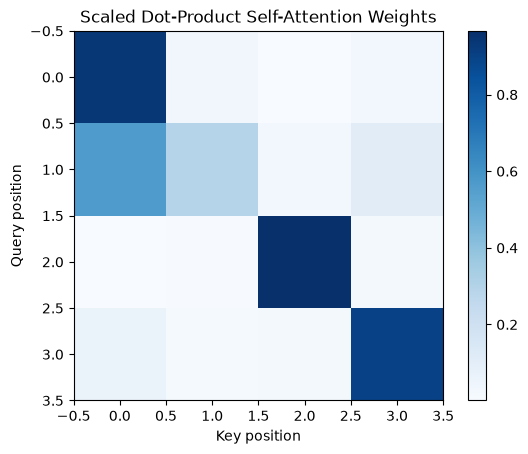

In [2]:
# =============================================================================
# TRANSFORMERS FROM SCRATCH
# PART 1: Scaled Dot-Product Attention (+ where Multi-Head fits)
# =============================================================================
#
# ---------------------------------------------------------------------------
# WHAT IS A TRANSFORMER? (deep but pictured)
# ---------------------------------------------------------------------------
# The 2017 paper "Attention Is All You Need" replaced RNNs for sequences with:
#   stacked blocks of  ATTENTION + MLP (feedforward), with residuals & layer-norm.
#
# Big idea vs RNN:
#   RNN: read left→right, one sticky note h (far words get smudged).
#   Transformer: every token can look at every other token IN PARALLEL
#                via attention — no step-by-step chain required.
#
# Two classic halves (we'll build both later in this notebook):
#   ENCODER — reads a full input sentence, builds rich contextual vectors
#             (BERT-style / translation "understand the source").
#   DECODER — generates output tokens one-by-one, attending to past outputs
#             AND to the encoder (GPT is decoder-only; original Transformer is both).
#
# One ENCODER block (simplified):
#   x → Multi-Head Self-Attention → add & norm → MLP → add & norm → x'
# One DECODER block adds:
#   masked self-attention (can't see future) + cross-attention to encoder.
#
# This PART 1 cell = the ATOM inside multi-head attention:
#   scaled_dot_product_attention(Q, K, V)
#
# ---------------------------------------------------------------------------
# SCALED DOT-PRODUCT ATTENTION (the atom)
# ---------------------------------------------------------------------------
# Same Q/K/V story as notebook 5:
#   Query  = "what am I looking for?"
#   Key    = "what do I advertise for matching?"
#   Value  = "what content do I give if matched?"
#
# Formula:
#   scores  = (Q @ K^T) / sqrt(d_k)     # similarity of every query to every key
#   weights = softmax(scores)           # each query row sums to 1
#   output  = weights @ V               # mix values
#
# Why /sqrt(d_k)?
#   Dot products grow with dimension. Without scaling, softmax becomes peaky
#   (almost one-hot) and gradients die. Scaling keeps scores in a nicer range.
#
# mask (optional):
#   Put True on positions you must IGNORE (e.g. future tokens in a decoder,
#   or padding). We set those scores to -1e9 → after softmax ≈ 0 weight.
#
# ---------------------------------------------------------------------------
# MULTI-HEAD ATTENTION (why "multi" — conceptual preview)
# ---------------------------------------------------------------------------
# One attention head = one view of the sentence (one set of Wq,Wk,Wv).
# Multi-head = run h heads in parallel on SPLIT pieces of the embedding,
#              then CONCAT their outputs and project with Wo.
#
# Intuition: one head might track "it → animal"; another tracks syntax;
#            another tracks nearby words. Different heads specialize.
#
# Shape sketch (batch omitted):
#   x: (seq, d_model)
#   split into h heads each of width d_k = d_model / h
#   each head: Attention(Q_i, K_i, V_i) → (seq, d_k)
#   concat heads → (seq, d_model) → @ Wo → (seq, d_model)
#
# Next cells will implement MultiHeadAttention; here we master the single
# attention function those heads all share.
#

import numpy as np
import matplotlib.pyplot as plt


def softmax(x, axis=-1):
    """Stable softmax: subtract max so exp() doesn't explode."""
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / np.sum(e_x, axis=axis, keepdims=True)


def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Core attention used inside every Transformer head.

    Q: (batch, seq_q, d_k)
    K: (batch, seq_k, d_k)
    V: (batch, seq_k, d_v)   # often d_v == d_k
    mask: (batch, seq_q, seq_k) bool — True = BLOCK this pair

    Returns:
      output:       (batch, seq_q, d_v)  mixed values per query position
      attn_weights: (batch, seq_q, seq_k) "how much q listens to each k"
    """
    d_k = Q.shape[-1]
    # (batch, seq_q, seq_k)
    scores = Q @ K.transpose(0, 2, 1) / np.sqrt(d_k)
    if mask is not None:
        scores = np.where(mask, -1e9, scores)  # blocked → ~0 after softmax
    attn_weights = softmax(scores, axis=-1)
    output = attn_weights @ V
    return output, attn_weights


# ---------------------------------------------------------------------------
# Tiny demo so you can SEE shapes + a heatmap
# ---------------------------------------------------------------------------
np.random.seed(0)
batch, seq, d_k = 1, 4, 8
# Pretend 4 token embeddings already projected into Q=K=V (self-attention toy)
Q = np.random.randn(batch, seq, d_k)
K = Q.copy()
V = Q.copy()

output, attn_weights = scaled_dot_product_attention(Q, K, V)

print("Q/K/V shape:", Q.shape)                 # (1, 4, 8)
print("Attention weights shape:", attn_weights.shape)  # (1, 4, 4) = 4 queries × 4 keys
print("Output shape:", output.shape)           # (1, 4, 8) — one new vector per token
print("Row 0 weights (sum→1):", np.round(attn_weights[0, 0], 3),
      " sum=", round(float(attn_weights[0, 0].sum()), 3))
print("Full weight matrix:\n", np.round(attn_weights[0], 3))

plt.imshow(attn_weights[0], cmap="Blues")
plt.colorbar()
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.title("Scaled Dot-Product Self-Attention Weights")
plt.show()

# How to read the output:
#   - weights[b, i, j] = how much token i copied from token j
#   - each weights row sums to ~1.0 (softmax)
#   - output[b, i] = mix of value vectors using that row
#   - heatmap: brighter = stronger attention
# Next: wrap this in Multi-Head (split → h attentions → concat → Wo)


In [ ]:
# =============================================================================
# MULTI-HEAD ATTENTION LAYER
# =============================================================================
# Builds on scaled_dot_product_attention from the previous cell.
#
# Easy picture:
#   One head  = one way of looking at the sentence.
#   Multi-head = several looks in parallel, then glue the results together.
#
# Pipeline:
#   1) Project x → Q, K, V with W_q, W_k, W_v   (full d_model width)
#   2) SPLIT the d_model channels into num_heads slices of width d_k
#   3) Run scaled_dot_product_attention on EACH head
#   4) CONCAT head outputs back to d_model
#   5) Final mix with W_o
#
# Shapes (this demo):
#   d_model=8, num_heads=2  →  d_k = 8/2 = 4
#   x: (1, 3, 8)  →  output: (1, 3, 8)  →  attn avg: (1, 3, 3)

class MultiHeadAttention:
    def __init__(self, d_model, num_heads):
        # d_model must split evenly across heads
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # width per head

        # Four learned matrices (He-ish scale for stable random start)
        scale = np.sqrt(2.0 / d_model)
        self.W_q = np.random.randn(d_model, d_model) * scale  # build queries
        self.W_k = np.random.randn(d_model, d_model) * scale  # build keys
        self.W_v = np.random.randn(d_model, d_model) * scale  # build values
        self.W_o = np.random.randn(d_model, d_model) * scale  # after concat

    def forward(self, Q, K, V, mask=None):
        """
        For self-attention call: forward(x, x, x)
        For cross-attention later: Q from decoder, K/V from encoder.
        mask: True = BLOCK. Must broadcast to (batch, seq_q, seq_k).
              (Our numpy attention has NO head axis — squeeze 4D PyTorch-style masks.)
        """
        assert Q.ndim == 3, f"Q must be (batch, seq, d_model), got {Q.shape}"

        # Fix common bug: (batch,1,1,seq) or (1,1,L,L) broadcast into scores → 4D → crash later
        if mask is not None:
            mask = np.asarray(mask)
            while mask.ndim > 3:
                # drop size-1 axes from the left/middle (head / singleton dims)
                squeezed = False
                for ax in range(mask.ndim - 1):
                    if mask.shape[ax] == 1:
                        mask = np.squeeze(mask, axis=ax)
                        squeezed = True
                        break
                if not squeezed:
                    break

        batch_size = Q.shape[0]

        # --- 1) Linear projections (still full d_model) ---
        Q_proj = Q @ self.W_q  # (batch, seq_q, d_model)
        K_proj = K @ self.W_k
        V_proj = V @ self.W_v

        # --- 2) Split channels into heads ---
        # (batch, seq, d_model) → (batch, num_heads, seq, d_k)
        def split_heads(x):
            batch, seq, _ = x.shape
            x = x.reshape(batch, seq, self.num_heads, self.d_k)
            return x.transpose(0, 2, 1, 3)

        Q_heads = split_heads(Q_proj)
        K_heads = split_heads(K_proj)
        V_heads = split_heads(V_proj)

        # --- 3) Attention per head (loop for clarity; production uses one big matmul) ---
        head_outputs = []
        attn_weights = []
        for h in range(self.num_heads):
            qh = Q_heads[:, h, :, :]  # (batch, seq_q, d_k)
            kh = K_heads[:, h, :, :]
            vh = V_heads[:, h, :, :]
            out_h, attn_h = scaled_dot_product_attention(qh, kh, vh, mask)
            head_outputs.append(out_h)   # each (batch, seq_q, d_k)
            attn_weights.append(attn_h)  # each (batch, seq_q, seq_k)

        # --- 4) Concat heads along feature axis → back to d_model ---
        concat = np.concatenate(head_outputs, axis=-1)  # (batch, seq_q, d_model)

        # --- 5) Output projection ---
        output = concat @ self.W_o

        # Average heads' heatmaps just for a simple viz (not used by the model math)
        avg_attn = np.mean(np.stack(attn_weights, axis=0), axis=0)
        return output, avg_attn


# --- Test ---
np.random.seed(0)
d_model = 8
num_heads = 2
mha = MultiHeadAttention(d_model, num_heads)
x = np.random.randn(1, 3, d_model)  # 1 batch, 3 tokens, 8-d each
output, attn = mha.forward(x, x, x)  # self-attention: Q=K=V=x

print("Input x shape:", x.shape)          # (1, 3, 8)
print("Output shape:", output.shape)      # (1, 3, 8) — same rank, contextualized
print("Attention shape:", attn.shape)     # (1, 3, 3) — avg over 2 heads
print("Attn row sums (~1):", np.round(attn[0].sum(axis=-1), 3))
# Expected prints:
#   Output shape: (1, 3, 8)
#   Attention shape: (1, 3, 3)
# Meaning: 3 tokens in → 3 richer vectors out; 3×3 = who listened to whom (averaged heads).


PE shape: (50, 64)
Position 0 (first 8 dims): [0. 1. 0. 1. 0. 1. 0. 1.]
Position 1 (first 8 dims): [0.841 0.54  0.682 0.732 0.533 0.846 0.409 0.912]


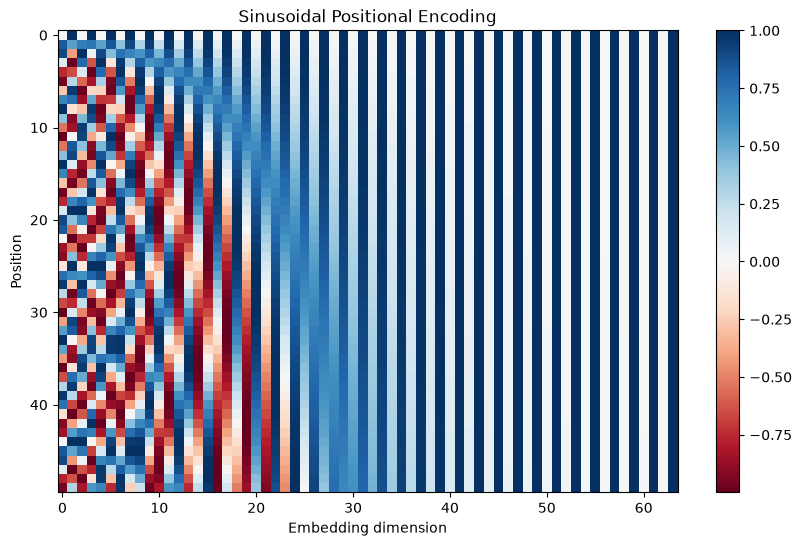

In [ ]:
# =============================================================================
# PART 2: POSITIONAL ENCODING
# =============================================================================
# Why we need it:
#   Self-attention treats the sentence like a BAG of tokens unless we tell it order.
#   (QK^T does not know if token A was before or after token B.)
#   RNNs got order "for free" by reading left→right. Transformers need an extra signal.
#
# How it "stamps" each spot (theater-seat picture):
#   Without PE: only meaning vectors — "king rules here" and "here rules king"
#   look the same to pure attention (same bag of words).
#
#   With PE: each seat gets its own stamp vector (sin/cos fingerprint):
#     stamp_0 ≈ [0.00, 1.00, ...]
#     stamp_1 ≈ [0.84, 0.54, ...]
#     stamp_2 ≈ [0.91,-0.42, ...]
#
#   Then ADD stamp to meaning (same width):
#     final[0] = embed("king")  + stamp_0
#     final[1] = embed("rules") + stamp_1
#     final[2] = embed("here")  + stamp_2
#
#   Keeping track:
#     Sentence A "king rules here" → king sits in seat 0 (king+stamp_0)
#     Sentence B "here rules king" → king sits in seat 2 (king+stamp_2)
#     Same word, different seats → different vectors → order is recoverable.
#
# Idea:
#   token_embedding + positional_encoding → model knows WHAT and WHERE.
#
# Terms:
#   position / pos     = index in the sequence (0, 1, 2, ... seq_len-1)
#   d_model            = embedding width (same size as token vectors, e.g. 64/512)
#   sinusoidal PE      = fixed sin/cos waves (Vaswani et al. 2017) — NOT learned
#   learned PE         = alternative: a trainable table PE[pos] (used in some models)
#
# Formula (even/odd feature pairs):
#   PE[pos, 2i]     = sin(pos / 10000^(2i/d_model))
#   PE[pos, 2i+1]   = cos(pos / 10000^(2i/d_model))
#   Different i → different wavelengths: low i = slow waves (long-range),
#   high i = fast waves (fine position detail). Together they fingerprint each pos.

# Sinusoidal Positional Encoding

def sinusoidal_positional_encoding(seq_len, d_model):
    """
    Build a (seq_len, d_model) matrix.
    Row p = the vector we ADD to the embedding of the token at position p.
    """
    PE = np.zeros((seq_len, d_model))
    for pos in range(seq_len):                 # each row = one position
        for i in range(0, d_model, 2):         # step by 2 → (sin, cos) pair
            denominator = 10000 ** (i / d_model)
            PE[pos, i] = np.sin(pos / denominator)
            if i + 1 < d_model:                # odd dim gets cos (if it exists)
                PE[pos, i + 1] = np.cos(pos / denominator)
    return PE


# --- Visualize ---
# Heatmap: rows = positions 0..49, columns = embedding dimensions 0..63
# Stripes/waves = the sin/cos patterns changing across positions.
d_model = 64
seq_len = 50
PE = sinusoidal_positional_encoding(seq_len, d_model)
print("PE shape:", PE.shape)  # (50, 64) — one 64-d vector per position
print("Position 0 (first 8 dims):", np.round(PE[0, :8], 3))
print("Position 1 (first 8 dims):", np.round(PE[1, :8], 3))
# Pos 0: sin(0)=0, cos(0)=1 pattern at the start of each pair
# Pos 1: slightly shifted waves — different fingerprint

plt.figure(figsize=(10, 6))
plt.imshow(PE, aspect="auto", cmap="RdBu")
plt.colorbar()
plt.xlabel("Embedding dimension")
plt.ylabel("Position")
plt.title("Sinusoidal Positional Encoding")
plt.show()

# In a real Transformer forward pass (later cells):
#   x = token_embed(token_ids) + PE[:seq_len]
# Then Multi-Head Attention sees both meaning and order.

# Why sinusoidal? It allows the model to attend to relative positions because PE[pos+k] can be 
# represented as a linear function of PE[pos]. Also works for arbitrary lengths.

In [ ]:
# =============================================================================
# PART 3: TRANSFORMER BLOCK — LayerNorm
# =============================================================================
# What is LayerNorm?
#   A "volume knob + recenter" for each token's feature vector.
#   After attention/MLP, some dimensions can explode (1000s) or vanish (~0).
#   LayerNorm forces that vector back to a friendly scale so the next layer
#   can keep learning.
#
# Steps (for ONE token's d_model features):
#   1) mean / variance across features (not across the batch)
#   2) x_norm = (x - mean) / sqrt(var + eps)   → ~zero mean, ~unit variance
#   3) out = gamma * x_norm + beta             → model can still stretch/shift
#      (gamma starts as 1s, beta as 0s; both are learned)
#
# Tiny example (d_model=4, one token):
#   raw features:     [10,  0, 10,  0]   mean=5,  messy scale
#   after normalize:  [~1, -1, ~1, -1]   centered, similar magnitude
#   after gamma/beta: still small & stable (gamma/beta fine-tune)
#
# Why use it in Transformers?
#   - Deep stacks (many blocks) stay trainable
#   - Works with batch size 1 (live inference / long chats)
#   - Applied per token → each seat keeps its own clean feature scale
#
# LayerNorm vs BatchNorm (quick):
#   BatchNorm: stats across the BATCH (needs big batches; awkward for NLP)
#   LayerNorm: stats across FEATURES of each example/token (Transformers' default)

class LayerNorm:
    def __init__(self, d_model, eps=1e-6):
        self.eps = eps
        self.gamma = np.ones(d_model)   # learned scale
        self.beta = np.zeros(d_model)   # learned shift

    def forward(self, x):
        # x: (batch, seq, d_model)
        mean = np.mean(x, axis=-1, keepdims=True)
        var = np.var(x, axis=-1, keepdims=True)
        x_norm = (x - mean) / np.sqrt(var + self.eps)
        return self.gamma * x_norm + self.beta

# --- Tiny demo ---
ln = LayerNorm(d_model=4)
x = np.array([[[10.0, 0.0, 10.0, 0.0],   # token 0
               [100.0, 100.0, 0.0, 0.0]]])  # token 1  (batch=1, seq=2, d=4)
y = ln.forward(x)
print("Before LayerNorm:", x[0])
print("After  LayerNorm:", np.round(y[0], 3))
print("Per-token mean after (~0):", np.round(y[0].mean(axis=-1), 3))
# Each row is re-centered on its own — token0 and token1 don't share a batch mean.


In [ ]:
# =============================================================================
# ENCODER BLOCK — "understand the source sentence"
# =============================================================================
# One encoder layer = two sublayers, each with residual skip + LayerNorm:
#
#   x ─► Multi-Head Self-Attention ─► (+) ─► LayerNorm ─► MLP(ReLU) ─► (+) ─► LayerNorm ─► out
#   │_______________________________|              │____________________|
#            residual connection                     residual connection
#
# Residual (x + sublayer(x)): keep the original signal so deep stacks train better.
# Self-attention here: every source token looks at every source token (Q=K=V=x).

class EncoderBlock:
    def __init__(self, d_model, num_heads, d_ff):
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        # Feed-forward: expand to d_ff then back to d_model (the "MLP" in the block)
        scale = np.sqrt(2.0 / d_model)
        self.W1 = np.random.randn(d_model, d_ff) * scale
        self.b1 = np.zeros(d_ff)
        self.W2 = np.random.randn(d_ff, d_model) * scale
        self.b2 = np.zeros(d_model)

    def forward(self, x, mask=None):
        # 1) Self-attention + residual + norm
        attn_out, _ = self.self_attn.forward(x, x, x, mask)
        x = self.norm1.forward(x + attn_out)
        # 2) Position-wise MLP + residual + norm
        ff_out = np.maximum(0, x @ self.W1 + self.b1) @ self.W2 + self.b2  # ReLU MLP
        x = self.norm2.forward(x + ff_out)
        return x  # same shape as input: (batch, src_len, d_model)


In [ ]:
# =============================================================================
# DECODER BLOCK — "write the answer, looking at the source"
# =============================================================================
# Three sublayers (each residual + LayerNorm):
#   1) MASKED self-attention on the target so far
#        (cannot peek at future answer tokens — look-ahead mask)
#   2) CROSS-attention: queries from decoder, keys/values from ENCODER output
#        (this is how the decoder "reads" the source sentence)
#   3) Feed-forward MLP (same idea as encoder)
#
# Easy story for translation / copy:
#   Encoder finished understanding "3 7 1 2".
#   Decoder, when writing the next digit, attends to encoder memory (cross-attn)
#   and to what it has already written (masked self-attn).

class DecoderBlock:
    def __init__(self, d_model, num_heads, d_ff):
        self.masked_self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.norm3 = LayerNorm(d_model)
        scale = np.sqrt(2.0 / d_model)
        self.W1 = np.random.randn(d_model, d_ff) * scale
        self.b1 = np.zeros(d_ff)
        self.W2 = np.random.randn(d_ff, d_model) * scale
        self.b2 = np.zeros(d_model)

    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        # 1) Masked self-attention over target tokens
        self_attn_out, _ = self.masked_self_attn.forward(x, x, x, tgt_mask)
        x = self.norm1.forward(x + self_attn_out)
        # 2) Cross-attention: Q=decoder, K/V=encoder
        cross_out, _ = self.cross_attn.forward(x, encoder_output, encoder_output, src_mask)
        x = self.norm2.forward(x + cross_out)
        # 3) MLP
        ff_out = np.maximum(0, x @ self.W1 + self.b1) @ self.W2 + self.b2
        x = self.norm3.forward(x + ff_out)
        return x


In [ ]:
# =============================================================================
# PART 4: FULL MINI TRANSFORMER (encoder–decoder)
# =============================================================================
# End-to-end flow:
#   src token ids  → embed + PE → Encoder stack → memory
#   tgt token ids  → embed + PE → Decoder stack (reads memory) → logits over vocab
#
# BUGFIX NOTE (masks):
#   Our attention uses scores shaped (batch, seq_q, seq_k).
#   Masks must broadcast to that — NOT (batch, 1, 1, seq) PyTorch-style 4D.
#   4D masks made np.where expand scores to 4D → next layer crashed with:
#     ValueError: too many values to unpack (expected 3) in split_heads.

class Transformer:
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=64, num_heads=4,
                 d_ff=128, num_layers=2, max_len=100):
        self.d_model = d_model
        self.embed_src = np.random.randn(src_vocab_size, d_model) * 0.1
        self.embed_tgt = np.random.randn(tgt_vocab_size, d_model) * 0.1
        self.pos_encoding = sinusoidal_positional_encoding(max_len, d_model)

        self.encoder_blocks = [EncoderBlock(d_model, num_heads, d_ff) for _ in range(num_layers)]
        self.decoder_blocks = [DecoderBlock(d_model, num_heads, d_ff) for _ in range(num_layers)]
        self.W_out = np.random.randn(d_model, tgt_vocab_size) * 0.1  # to vocab logits

    def encode(self, src_tokens, src_mask=None):
        # src_tokens: (batch, src_len) ints → (batch, src_len, d_model)
        x = self.embed_src[src_tokens] + self.pos_encoding[: src_tokens.shape[1]]
        for encoder in self.encoder_blocks:
            x = encoder.forward(x, src_mask)
        return x  # encoder "memory"

    def decode(self, tgt_tokens, encoder_output, src_mask=None, tgt_mask=None):
        x = self.embed_tgt[tgt_tokens] + self.pos_encoding[: tgt_tokens.shape[1]]
        for decoder in self.decoder_blocks:
            x = decoder.forward(x, encoder_output, src_mask, tgt_mask)
        return x @ self.W_out  # (batch, tgt_len, tgt_vocab)

    def forward(self, src_tokens, tgt_tokens, src_mask=None, tgt_mask=None):
        enc_out = self.encode(src_tokens, src_mask)
        return self.decode(tgt_tokens, enc_out, src_mask, tgt_mask)


def create_padding_mask(seq, pad_idx=0):
    """True where PAD — block attending TO those key positions.
    Shape (batch, 1, seq_len) → broadcasts over queries as (batch, seq_q, seq_k).
    """
    return (seq == pad_idx)[:, np.newaxis, :]  # (batch, 1, seq)


def create_look_ahead_mask(size):
    """True on FUTURE positions (upper triangle) — decoder cannot peek ahead.
    Shape (1, size, size) → broadcasts over batch.
    """
    mask = np.triu(np.ones((size, size)), k=1).astype(bool)
    return mask[np.newaxis, :, :]  # (1, size, size)


In [ ]:
# =============================================================================
# PART 5: TINY TASK — COPY (teaches encoder–decoder without real language)
# =============================================================================
# Goal: input digits → output the SAME digits (plus SOS/EOS bookends).
# Example:  src  [3, 7, 1, 2]
#           tgt_in  (what decoder SEES during teacher forcing):
#                    [SOS, 3, 7, 1, 2, PAD]
#           tgt_out (what we TRAIN it to PREDICT at each step):
#                    [3, 7, 1, 2, EOS, PAD]
#
# Terms:
#   SOS = start-of-sequence token (tells decoder to start)
#   EOS = end-of-sequence
#   PAD = filler / ignore in loss
#   teacher forcing = feed correct previous tokens as tgt_in (training trick)

src_vocab_size = 11   # digits 1-9 + PAD=0  (0 reserved)
tgt_vocab_size = 12   # + SOS=10 + EOS=11
SOS, EOS, PAD = 10, 11, 0


def generate_copy_batch(batch_size, seq_len, vocab_size=10):
    src = np.random.randint(1, vocab_size, size=(batch_size, seq_len))
    tgt_input = np.ones((batch_size, seq_len + 2), dtype=int) * PAD
    tgt_input[:, 0] = SOS
    tgt_input[:, 1 : seq_len + 1] = src
    tgt_output = np.ones((batch_size, seq_len + 2), dtype=int) * PAD
    tgt_output[:, :seq_len] = src
    tgt_output[:, seq_len] = EOS
    return src, tgt_input, tgt_output


# Demo batch
np.random.seed(0)
src, tgt_in, tgt_out = generate_copy_batch(2, 4)
print("Source:       ", src)
print("Target input: ", tgt_in)
print("Target output:", tgt_out)
# Read one row: decoder sees SOS then digits; should predict digits then EOS.


In [ ]:
# =============================================================================
# FORWARD + LOSS (structure demo — no full NumPy backprop yet)
# =============================================================================
# Flow for one batch:
#   src, tgt_in → masks → model.forward → logits (batch, tgt_len, vocab)
#   compare logits to tgt_out with cross-entropy (ignore PAD)
#
# Why no training to convergence here:
#   Full backprop through MHA/masks by hand is huge; Week/ later = PyTorch mini-GPT.
#   You still verify the FORWARD architecture works end-to-end.

np.random.seed(1)
model = Transformer(src_vocab_size, tgt_vocab_size, d_model=64, num_heads=4, num_layers=2)

batch_size, seq_len = 2, 4
src, tgt_in, tgt_out = generate_copy_batch(batch_size, seq_len)

src_mask = create_padding_mask(src, PAD)                 # (2, 1, 4)
tgt_mask = create_look_ahead_mask(tgt_in.shape[1])       # (1, 6, 6)

print("src_mask shape:", src_mask.shape, " tgt_mask shape:", tgt_mask.shape)

logits = model.forward(src, tgt_in, src_mask, tgt_mask)
print("Logits shape:", logits.shape)  # expect (2, 6, 12) = batch × tgt_len × vocab


def softmax_cross_entropy(logits, targets, pad_idx=PAD):
    # logits: (batch, seq, vocab), targets: (batch, seq)
    vocab = logits.shape[-1]
    logits_flat = logits.reshape(-1, vocab)
    targets_flat = targets.reshape(-1)
    keep = targets_flat != pad_idx
    logits_flat = logits_flat[keep]
    targets_flat = targets_flat[keep]
    probs = softmax(logits_flat)
    return -np.mean(np.log(probs[np.arange(len(targets_flat)), targets_flat] + 1e-8))


loss = softmax_cross_entropy(logits, tgt_out)
print("Loss:", float(loss))
# Random weights → loss roughly near log(vocab) ≈ 2.5; finite = forward path is healthy.
#
# Takeaway: this is the same skeleton as nn.Transformer / GPT stacks —
# embed+PE → blocks(attn+ff) → logits — just smaller and NumPy-only.
